In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All imports successful!")

All imports successful!


In [2]:
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print("Fraud_Data shape:", fraud_df.shape)
print("IpAddress_to_Country shape:", ip_df.shape)
fraud_df.head()

Fraud_Data shape: (151112, 11)
IpAddress_to_Country shape: (138846, 3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
print("=== DATA TYPES ===")
print(fraud_df.dtypes)
print("\n=== MISSING VALUES ===")
print(fraud_df.isnull().sum())
print("\n=== DUPLICATES ===")
print("Duplicate rows:", fraud_df.duplicated().sum())

=== DATA TYPES ===
user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

=== MISSING VALUES ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [4]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print("Dtypes after fix:")
print(fraud_df[['signup_time', 'purchase_time']].dtypes)

Dtypes after fix:
signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object


Class distribution:
class
0    136961
1     14151
Name: count, dtype: int64

Fraud rate: 9.36%


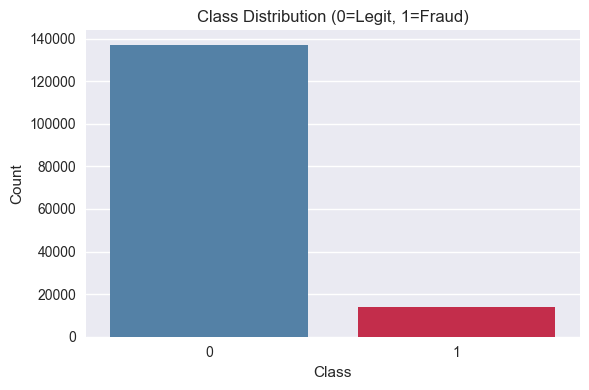

In [5]:
class_counts = fraud_df['class'].value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nFraud rate: {class_counts[1]/len(fraud_df)*100:.2f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=fraud_df, palette=['steelblue','crimson'])
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png')
plt.show()

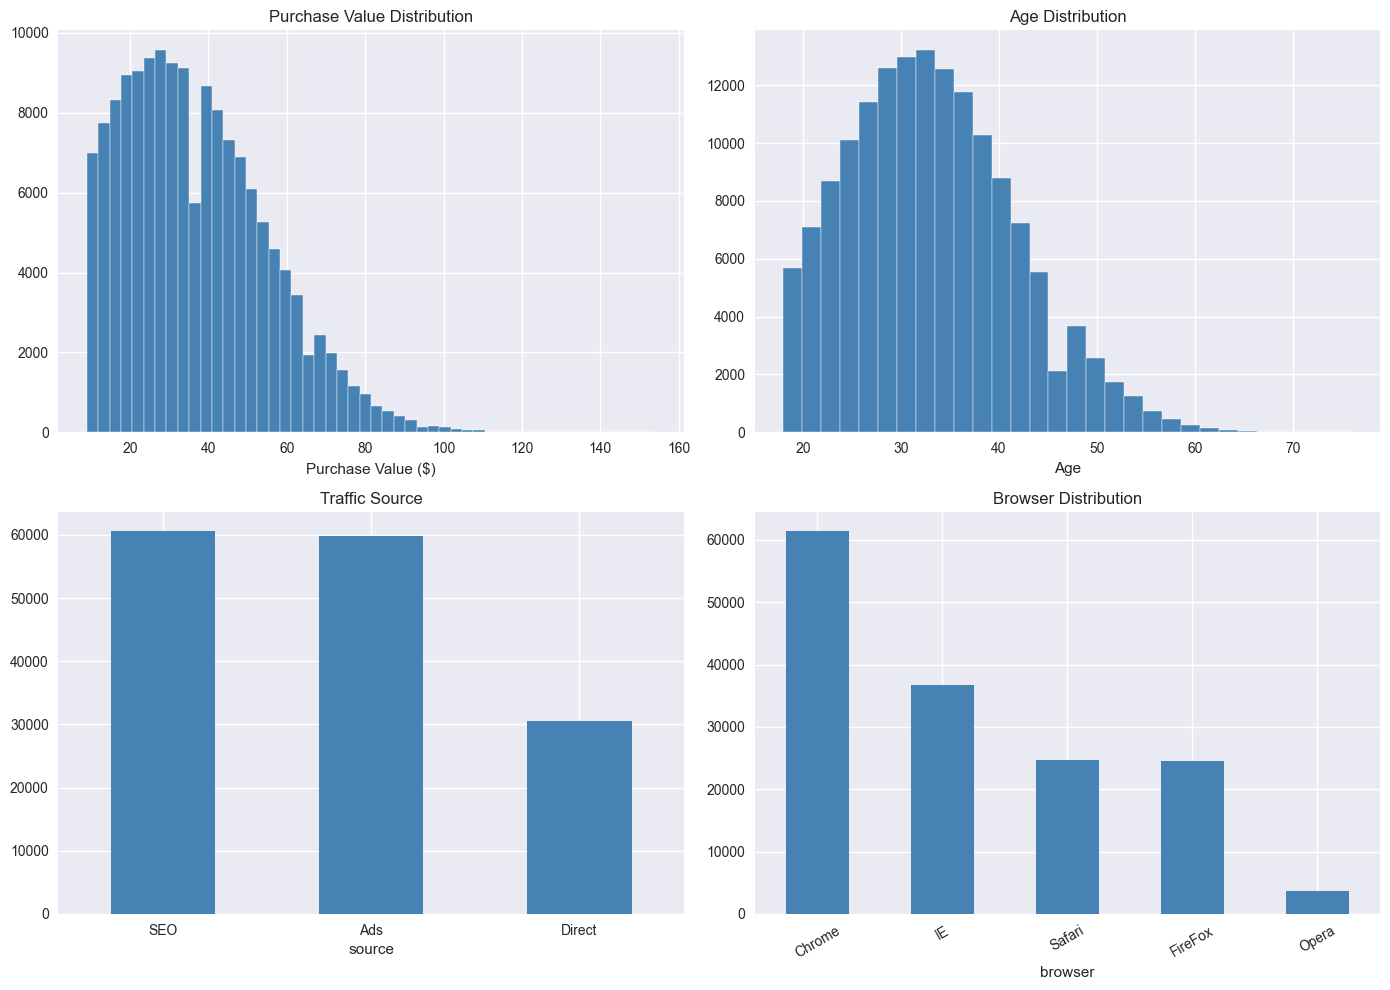

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Purchase value distribution
axes[0,0].hist(fraud_df['purchase_value'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Purchase Value Distribution')
axes[0,0].set_xlabel('Purchase Value ($)')

# Age distribution
axes[0,1].hist(fraud_df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Source
fraud_df['source'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Traffic Source')
axes[1,0].tick_params(axis='x', rotation=0)

# Browser
fraud_df['browser'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Browser Distribution')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/univariate_eda.png')
plt.show()

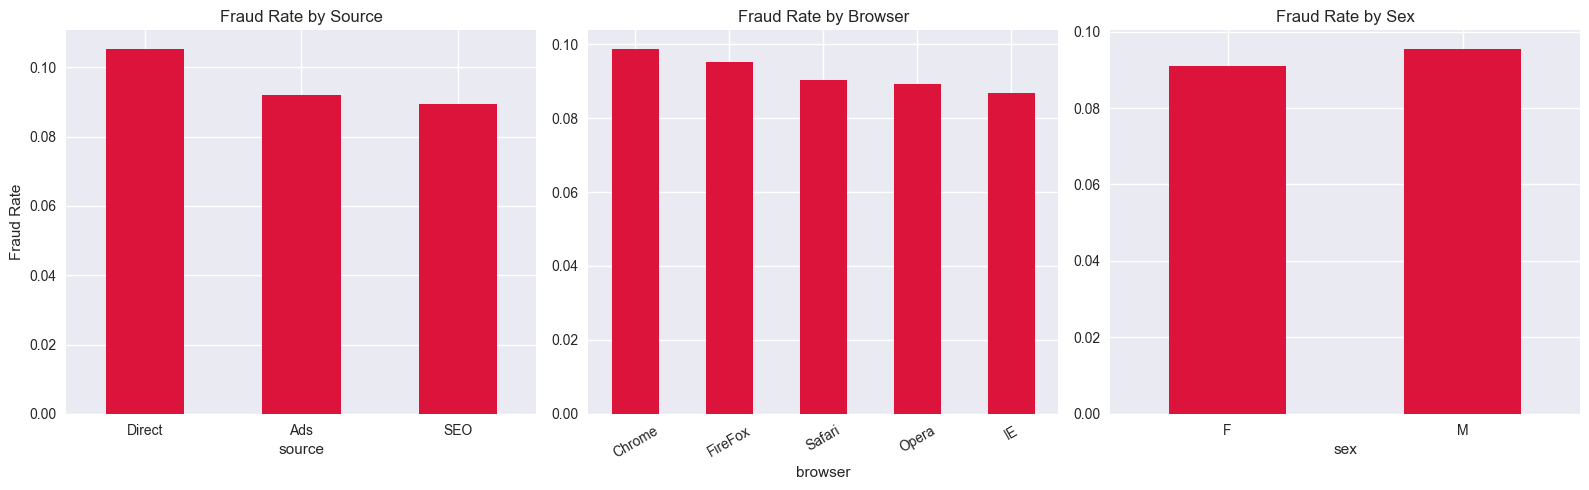

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fraud rate by source
fraud_by_source = fraud_df.groupby('source')['class'].mean().sort_values(ascending=False)
fraud_by_source.plot(kind='bar', ax=axes[0], color='crimson')
axes[0].set_title('Fraud Rate by Source')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=0)

# Fraud rate by browser
fraud_by_browser = fraud_df.groupby('browser')['class'].mean().sort_values(ascending=False)
fraud_by_browser.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Fraud Rate by Browser')
axes[1].tick_params(axis='x', rotation=30)

# Fraud rate by sex
fraud_by_sex = fraud_df.groupby('sex')['class'].mean()
fraud_by_sex.plot(kind='bar', ax=axes[2], color='crimson')
axes[2].set_title('Fraud Rate by Sex')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/bivariate_eda.png')
plt.show()

In [8]:
# time_since_signup in hours
fraud_df['time_since_signup'] = (
    fraud_df['purchase_time'] - fraud_df['signup_time']
).dt.total_seconds() / 3600

# Hour of day and day of week
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

# Transaction frequency per user
fraud_df['user_txn_count'] = fraud_df.groupby('user_id')['user_id'].transform('count')

print("New features added:")
print(fraud_df[['time_since_signup', 'hour_of_day', 'day_of_week', 'user_txn_count']].describe())

New features added:
       time_since_signup    hour_of_day    day_of_week  user_txn_count
count      151112.000000  151112.000000  151112.000000        151112.0
mean         1370.008125      11.521593       3.011819             1.0
std           868.406422       6.912474       2.006203             0.0
min             0.000278       0.000000       0.000000             1.0
25%           607.431528       6.000000       1.000000             1.0
50%          1368.429306      12.000000       3.000000             1.0
75%          2123.479028      17.000000       5.000000             1.0
max          2879.992222      23.000000       6.000000             1.0


In [9]:
# Convert IP to integer
def ip_to_int(ip):
    try:
        parts = str(int(ip)).zfill(10)
        return int(ip)
    except:
        return 0

fraud_df['ip_int'] = fraud_df['ip_address'].astype(np.int64)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(np.int64)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(np.int64)

# Sort for merge_asof
fraud_sorted = fraud_df.sort_values('ip_int').reset_index(drop=True)
ip_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)

# Range-based merge
merged = pd.merge_asof(
    fraud_sorted,
    ip_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Keep only valid matches
merged['country'] = merged.apply(
    lambda r: r['country'] if r['ip_int'] <= r['upper_bound_ip_address'] else 'Unknown',
    axis=1
)

print("Country mapping done!")
print(merged['country'].value_counts().head(10))

Country mapping done!
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


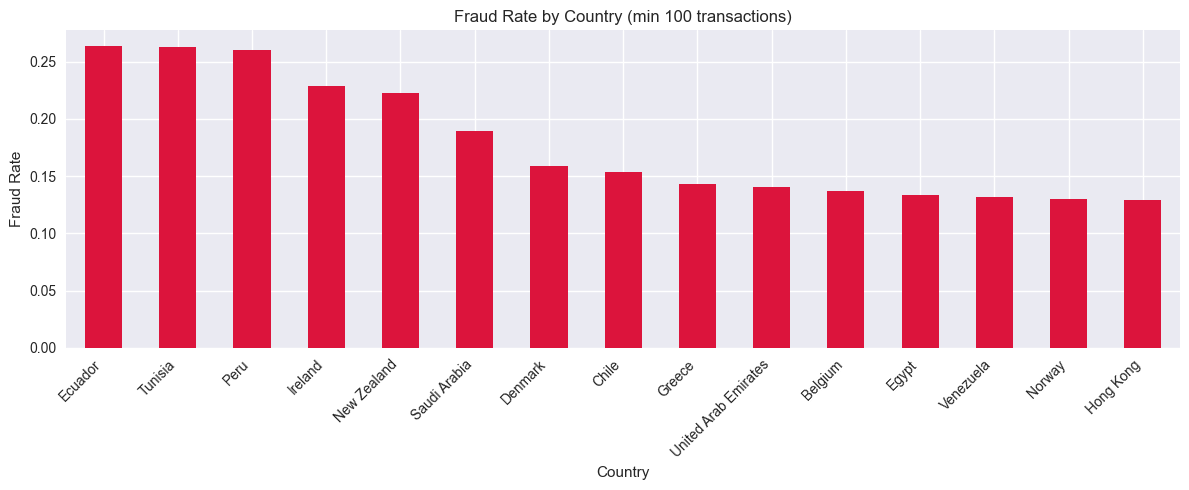

In [10]:
fraud_by_country = merged.groupby('country')['class'].agg(['mean', 'count'])
fraud_by_country.columns = ['fraud_rate', 'total_txns']
fraud_by_country = fraud_by_country[fraud_by_country['total_txns'] > 100]
fraud_by_country = fraud_by_country.sort_values('fraud_rate', ascending=False).head(15)

plt.figure(figsize=(12, 5))
fraud_by_country['fraud_rate'].plot(kind='bar', color='crimson')
plt.title('Fraud Rate by Country (min 100 transactions)')
plt.ylabel('Fraud Rate')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/fraud_by_country.png')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

# Work on merged dataframe
df = merged.copy()

# Drop columns not needed for modeling
df = df.drop(columns=['signup_time', 'purchase_time', 'device_id', 
                       'ip_address', 'ip_int', 'lower_bound_ip_address', 
                       'upper_bound_ip_address', 'user_id'])

# One-hot encode categoricals
df = pd.get_dummies(df, columns=['source', 'browser', 'sex', 'country'], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['purchase_value', 'age', 'time_since_signup', 
            'hour_of_day', 'day_of_week', 'user_txn_count']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Final shape:", df.shape)
print("Class distribution after preprocessing:")
print(df['class'].value_counts())
df.head()

Final shape: (151112, 195)
Class distribution after preprocessing:
class
0    136961
1     14151
Name: count, dtype: int64


,purchase_value,age,class,time_since_signup,hour_of_day,day_of_week,user_txn_count,source_Direct,source_SEO,browser_FireFox,...,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,0.494721,0.331793,0,-1.013679,-0.220124,1.489476,0.0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
1,-0.214781,-0.364448,0,-1.230613,0.792542,0.492565,0.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,-0.214781,-0.132367,0,-1.337931,-0.509456,-1.002803,0.0,True,False,True,...,True,False,False,False,False,False,False,False,False,False
3,-0.214781,0.795954,0,0.800513,1.371208,-0.005891,0.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,0.985915,0.563874,0,-1.127359,-0.654123,1.489476,0.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['class'])
y = df['class']

# Stratified split FIRST, then SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# Save processed data
import os
os.makedirs('../data/processed', exist_ok=True)

pd.DataFrame(X_train_sm).to_csv('../data/processed/X_train_fraud.csv', index=False)
pd.DataFrame(X_test).to_csv('../data/processed/X_test_fraud.csv', index=False)
pd.Series(y_train_sm).to_csv('../data/processed/y_train_fraud.csv', index=False)
pd.Series(y_test).to_csv('../data/processed/y_test_fraud.csv', index=False)

print("\nData saved to data/processed/")

Before SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64

After SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64

Data saved to data/processed/
